# Keyword analysis

Keyword analysis asks which words are distinctive of one collection of texts. Two corpora are compared: the **target**, whose keywords we want, and the **reference** it is measured against. A word is a keyword when it is more frequent in the target than the reference frequency leads us to expect. The reference corpus establishes a baseline of comparison that we use to evaluate the words used in the target corpus.

Here we compare how men and women talk in the spoken part of the BNC, first with the chi-sq statistic (Rayson, et al. 1997), then with the t-test of Lijffijt et al. (2016), and finally we ask how much the two rankings agree.


**References**

- Rayson, P., Leech, G., and Hodges, M. 1997. Social differentiation in the use of English vocabulary: some analyses of the conversational component of the British National Corpus. *International Journal of Corpus Linguistics*. 2(1): 133-152.
- Lijffijt, J., T. Nevalainen, T. Säily, P. Papapetrou, K. Puolamäki, and H. Mannila. 2016. Significance testing of word frequencies in corpora. *Digital       Scholarship in the Humanities* 31(2): 374-397.


In [53]:
import polars as pl
import polars_corpus as plc
from scipy.stats import spearmanr

import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_rows(20)
pl.Config.set_float_precision(3)
pl.Config.set_thousands_separator(",")

polars.config.Config

In [54]:
pl.Config.set_tbl_rows(25)
pl.Config.set_float_precision(3)

polars.config.Config

## The corpus

We read the BNC and its speaker metadata, keep the speakers whose sex is recorded, and restrict the corpus to face-to-face conversation (`CONVRSN`). Joining the two adds a `sex` column to every token, which is what the target and reference corpora are filtered on below; the `group_by` is just a sanity check on how many speakers of each are left.


In [55]:
bnc = pl.scan_parquet("../../data/bnc.parquet").set_sorted("file_id")
speakers = pl.scan_parquet("../../data/bnc-speakers.parquet")

speakers = speakers.filter(pl.col("sex").is_in(["m", "f"]))
speakers.group_by("sex").len()

bnc = (
    bnc.filter(pl.col("text_type") == "CONVRSN")
    .join(speakers, on="speaker_id", how="inner")
    .with_columns(pl.col("token").str.to_lowercase().alias("norm"))
)

## Keyness by log-likelihood

The classic approach counts each word in the target and in the reference and tests the resulting 2x2 table for independence. With `method='ll'` that test is
the log-likelihood ratio $G^2$, which measures how far the observed counts fall from the counts we would expect if the word were spread across the two corpora
in proportion to their sizes. It is reported in the `LogLik` column, with the words most specific to the target first.

Swapping `target` and `reference` gives the other side of the comparison: the words distinctive of women's speech rather than men's. The two calls are separate analyses, not two halves of one, so each is ranked on its own.

In [96]:
mens_keywords = (
    plc.keywords(
        target=bnc.filter(pl.col("sex") == "m"),
        reference=bnc.filter(pl.col("sex") == "f"),
        method="ll",
        expr=pl.col("token").str.to_lowercase(),
    )
    .filter(plc.is_letters("token"))
    .head(100)
    .select("token", "target_df", "LogLik")
    .collect(engine="streaming")
)
mens_keywords.head(10)

token,target_df,LogLik
str,u32,f64
"""fucking""",47,"1,237.921"
"""er""",130,900.794
"""the""",134,574.377
"""yeah""",131,305.647
"""minus""",10,299.750
"""aye""",66,258.852
"""hundred""",96,249.382
"""right""",126,249.237
"""fuck""",39,238.648


In [63]:
womens_keywords = (
    plc.keywords(
        target=bnc.filter(pl.col("sex") == "f"),
        reference=bnc.filter(pl.col("sex") == "m"),
        method="ll",
        expr=pl.col("token").str.to_lowercase(),
    )
    .filter(plc.is_letters("token"))
    .select("token", "target_df", "LogLik")
    .collect(engine="streaming")
)
womens_keywords.head(10)

token,target_df,LogLik
str,u32,f64
"""she""",130,"3,373.992"
"""her""",129,"1,017.036"
"""said""",131,915.451
"""n't""",135,494.184
"""i""",137,369.237
"""and""",136,271.296
"""to""",135,207.086
"""cos""",129,204.473
"""christmas""",86,175.169


`keyword_plot` draws a ranked list as a lollipop chart, one stem per word,
positioned by its keyness score.

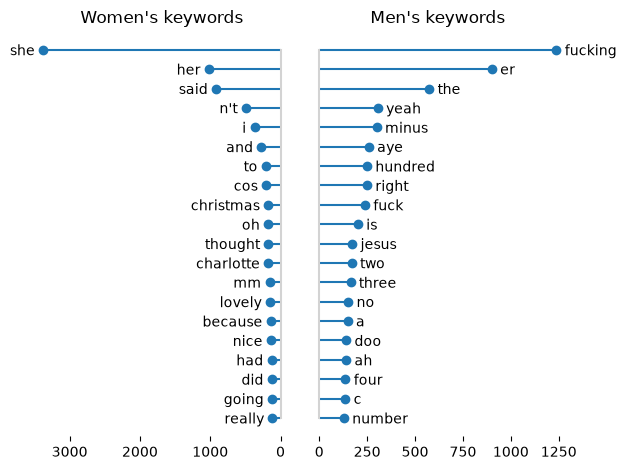

In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
plc.keyword_plot(
    womens_keywords, "token", "LogLik", ax=ax1, top_k=20, descending=True, reverse=True
)
ax1.set_title("Women's keywords")
plc.keyword_plot(mens_keywords, "token", "LogLik", ax=ax2, top_k=20, descending=True)
ax2.set_title("Men's keywords")
plt.tight_layout()

## Keyness as a difference in rates

$G^2$ pools each corpus into a single bag of words, so a word one talkative speaker uses frequently has the same impact as one used occasionally by many different speakers.

Lijffijt et al. (2016) argue for treating corpus samples as the unit of observation instead: compute the relative frequency of the word in each file and compare the two sets of rates with Welch's t-test. Files where the word never occurs count as a rate of zero, so a word confined to a few speakers gets a low mean and a large variance, and lands well down the list.

That is `method='ttest'`, which returns only the words more frequent in the target, ranked by `p` ascending. `t` and `p` measure the evidence that the rates
differ and `df` is Welch's adjusted degrees of freedom; `g` is Hedges' $g$, the effect size, which is what to rank by when the question is how big the
difference is rather than how sure we are of it.

In [86]:
tt_mens_keywords = plc.keywords(
    target=bnc.filter(pl.col("sex") == "m"),
    reference=bnc.filter(pl.col("sex") == "f"),
    method="ttest",
    expr=pl.col("token").str.to_lowercase(),
).collect()
tt_mens_keywords

token,t,p,df,g
str,f64,f64,f64,f64
"""er""",3.979,0.000,207.298,0.480
"""which""",3.687,0.000,192.910,0.445
"""c""",3.657,0.000,201.534,0.442
"""quid""",3.537,0.000,231.138,0.427
"""ah""",3.418,0.001,206.286,0.413
"""hundred""",3.346,0.001,240.972,0.404
"""against""",3.331,0.001,197.162,0.402
"""chap""",3.153,0.002,159.891,0.380
"""mate""",3.151,0.002,163.768,0.380


In [87]:
tt_womens_keywords = plc.keywords(
    target=bnc.filter(pl.col("sex") == "f"),
    reference=bnc.filter(pl.col("sex") == "m"),
    method="ttest",
    expr=pl.col("token").str.to_lowercase(),
).collect()
tt_womens_keywords.sort(by="g", descending=True)

token,t,p,df,g
str,f64,f64,f64,f64
"""she""",7.102,0.000,214.777,0.856
"""her""",4.983,0.000,270.939,0.602
"""to""",4.964,0.000,270.949,0.599
"""lovely""",4.706,0.000,203.745,0.567
"""children""",3.961,0.000,241.274,0.478
"""did""",3.932,0.000,262.944,0.474
"""shopping""",3.923,0.000,183.692,0.472
"""likes""",3.842,0.000,195.918,0.463
"""really""",3.837,0.000,228.945,0.463


The same back-to-back plot, now positioned by effect size rather than $G^2$.
Note how much shorter the lists' shared vocabulary is: ranking by $g$ promotes
words that most speakers of one group use a little more often over words that a
few of them use a great deal.

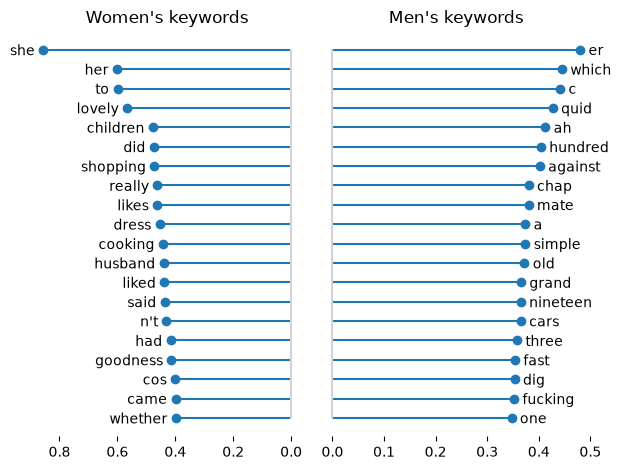

In [88]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
plc.keyword_plot(
    tt_womens_keywords, "token", "g", ax=ax1, top_k=20, descending=True, reverse=True
)
ax1.set_title("Women's keywords")
plc.keyword_plot(tt_mens_keywords, "token", "g", ax=ax2, top_k=20, descending=True)
ax2.set_title("Men's keywords")
plt.tight_layout()

## Do the two measures agree?

Joining the two women's keyword tables on `token` puts each word's `LogLik` and its t score side by side. The join is inner and the t-test table was cut to
its top 500, so this compares the two measures over the words the t-test ranks highest.

Spearman's rank correlation asks whether the two measures order those words the same way, and the scatter plot -- with $G^2$ on a log scale, since it spans orders of magnitude -- shows where they diverge. 

In [92]:
both = tt_womens_keywords.head(500).join(womens_keywords, how="inner", on="token")

In [93]:
spearmanr(both["LogLik"], both["t"])

SignificanceResult(statistic=np.float64(0.5016223388449035), pvalue=np.float64(3.205435702046297e-33))

[]

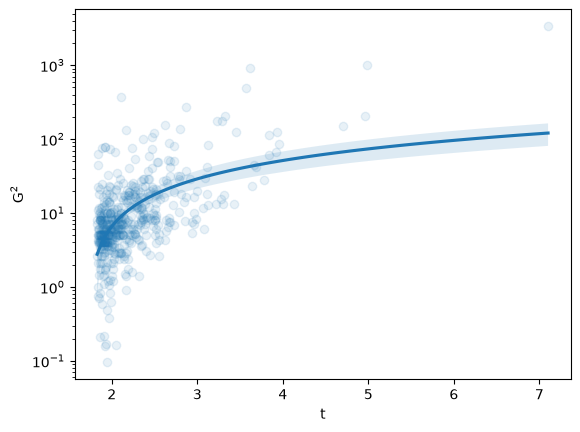

In [95]:
sns.regplot(both, x="t", y="LogLik", robust=True, scatter_kws=dict(alpha=0.1))
plt.xlabel("t")
plt.ylabel("G$^2$")
plt.semilogy()